In [ ]:
# CELL 1 in new Colab notebook:
# ScreenMind_Risk_Model.ipynb

# GENERATE SYNTHETIC SLEEP RISK DATASET
# Based on real research findings from literature

import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import random

np.random.seed(42)
random.seed(42)

def generate_sleep_dataset(n_users=200, n_days=60):
    """
    Generate realistic synthetic sleep risk dataset.

    Based on published research findings:
    - Late screen time strongly correlates with poor sleep
    - High unlock count indicates sleep disruption
    - Social media use before bed delays sleep onset

    Returns: DataFrame with daily records
    """

    records = []

    for user_id in range(n_users):

        # Assign user profile (determines baseline behavior)
        profile = random.choices(
            ['healthy', 'moderate', 'problematic'],
            weights=[0.30, 0.45, 0.25]
        )[0]

        # Profile-based baseline parameters
        if profile == 'healthy':
            base_screen_time = random.uniform(10, 40)
            base_unlocks = random.uniform(1, 4)
            base_social_media = random.uniform(5, 25)
            base_sleep_hour = random.uniform(22, 23.5)
        elif profile == 'moderate':
            base_screen_time = random.uniform(30, 80)
            base_unlocks = random.uniform(3, 8)
            base_social_media = random.uniform(20, 60)
            base_sleep_hour = random.uniform(23, 24.5)
        else:  # problematic
            base_screen_time = random.uniform(70, 180)
            base_unlocks = random.uniform(7, 18)
            base_social_media = random.uniform(50, 120)
            base_sleep_hour = random.uniform(0, 2.5)

        for day in range(n_days):

            # Add day-of-week effect
            day_of_week = day % 7
            is_weekend = day_of_week >= 5
            weekend_factor = 1.3 if is_weekend else 1.0

            # Add some random variation per day
            noise = random.uniform(0.7, 1.3)

            # Calculate daily features
            screen_time_night = max(0,
                base_screen_time * weekend_factor * noise +
                random.gauss(0, 10))

            unlocks_night = max(0,
                base_unlocks * weekend_factor * noise +
                random.gauss(0, 1))

            social_media_mins = max(0,
                base_social_media * weekend_factor * noise +
                random.gauss(0, 8))

            # Last screen off time (hours after midnight)
            last_screen_off = max(21, min(28,
                base_sleep_hour + random.gauss(0, 0.8)))

            # Convert to hour of day (0-24)
            last_screen_off_normalized = last_screen_off % 24

            notifications_night = max(0,
                unlocks_night * 2.5 + random.gauss(0, 3))

            # Snoring (random, influenced by fatigue)
            snoring_mins = max(0,
                np.random.exponential(10) if random.random() > 0.6
                else 0)

            # Restlessness (influenced by screen time)
            restlessness = max(0, min(100,
                (screen_time_night / 180) * 60 +
                random.uniform(0, 40)))

            # Calculate PSQI-like sleep quality score
            # Higher = worse sleep (0-21 scale)
            psqi_score = calculate_psqi(
                screen_time_night,
                unlocks_night,
                social_media_mins,
                last_screen_off,
                snoring_mins
            )

            # Risk label from PSQI
            # PSQI 0-4: Good sleep (LOW)
            # PSQI 5-10: Poor sleep (MODERATE)
            # PSQI 11+: Very poor (HIGH)
            if psqi_score <= 4:
                risk_label = 0  # LOW
            elif psqi_score <= 10:
                risk_label = 1  # MODERATE
            else:
                risk_label = 2  # HIGH

            records.append({
                'user_id': user_id,
                'day': day,
                'day_of_week': day_of_week,
                'is_weekend': int(is_weekend),
                'profile': profile,

                # Features (what app collects)
                'screen_time_night_mins': round(screen_time_night, 1),
                'unlocks_night': round(unlocks_night),
                'notifications_night': round(notifications_night),
                'social_media_mins': round(social_media_mins, 1),
                'last_screen_off_hour': round(last_screen_off_normalized, 2),
                'snoring_mins': round(snoring_mins, 1),
                'restlessness_percent': round(restlessness, 1),

                # Label (what we predict)
                'psqi_score': round(psqi_score, 1),
                'risk_label': risk_label,
                'risk_name': ['LOW', 'MODERATE', 'HIGH'][risk_label],
            })

    return pd.DataFrame(records)


def calculate_psqi(screen_time, unlocks,
                   social_media, last_screen_off, snoring):
    """
    Calculate PSQI-like score based on behavioral features.
    Based on published correlations from sleep research.
    """
    score = 0

    # Screen time component (0-3)
    if screen_time > 120: score += 3
    elif screen_time > 60: score += 2
    elif screen_time > 30: score += 1

    # Sleep latency from late phone use (0-3)
    # After midnight = significant impact
    if last_screen_off > 24: score += 3  # after midnight
    elif last_screen_off > 23: score += 2
    elif last_screen_off > 22: score += 1

    # Unlock disruption (0-3)
    if unlocks > 10: score += 3
    elif unlocks > 6: score += 2
    elif unlocks > 3: score += 1

    # Social media (0-3)
    if social_media > 80: score += 3
    elif social_media > 45: score += 2
    elif social_media > 20: score += 1

    # Snoring (0-3)
    if snoring > 40: score += 3
    elif snoring > 20: score += 2
    elif snoring > 10: score += 1

    # Add slight random noise
    score += random.gauss(0, 0.5)

    return max(0, min(21, score))


# Generate the dataset
print("🔄 Generating synthetic dataset...")
df = generate_sleep_dataset(n_users=200, n_days=60)

print(f"\n✅ Dataset generated!")
print(f"Total records: {len(df)}")
print(f"Unique users: {df['user_id'].nunique()}")
print(f"\nRisk Distribution:")
print(df['risk_name'].value_counts())
print(f"\nPercentages:")
print(df['risk_name'].value_counts(normalize=True) * 100)

print(f"\nSample rows:")
print(df.head())

🔄 Generating synthetic dataset...

✅ Dataset generated!
Total records: 12000
Unique users: 200

Risk Distribution:
risk_name
MODERATE    8111
LOW         3557
HIGH         332
Name: count, dtype: int64

Percentages:
risk_name
MODERATE    67.591667
LOW         29.641667
HIGH         2.766667
Name: proportion, dtype: float64

Sample rows:
   user_id  day  day_of_week  is_weekend   profile  screen_time_night_mins  \
0        0    0            0           0  moderate                    37.9   
1        0    1            1           0  moderate                    27.3   
2        0    2            2           0  moderate                    33.5   
3        0    3            3           0  moderate                    41.5   
4        0    4            4           0  moderate                    23.9   

   unlocks_night  notifications_night  social_media_mins  \
0              5                   12               30.3   
1              5                   17               19.2   
2           

In [ ]:
# CELL 2: Save and Download the Dataset

# 1. Save the dataframe to a CSV file in the Colab server
file_name = 'ScreenMind_Sleep_Dataset.csv'
df.to_csv(file_name, index=False)

# 2. Use the Colab files utility to download it to your local computer
from google.colab import files
files.download(file_name)

print(f"✅ {file_name} has been saved and the download has started!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ ScreenMind_Sleep_Dataset.csv has been saved and the download has started!


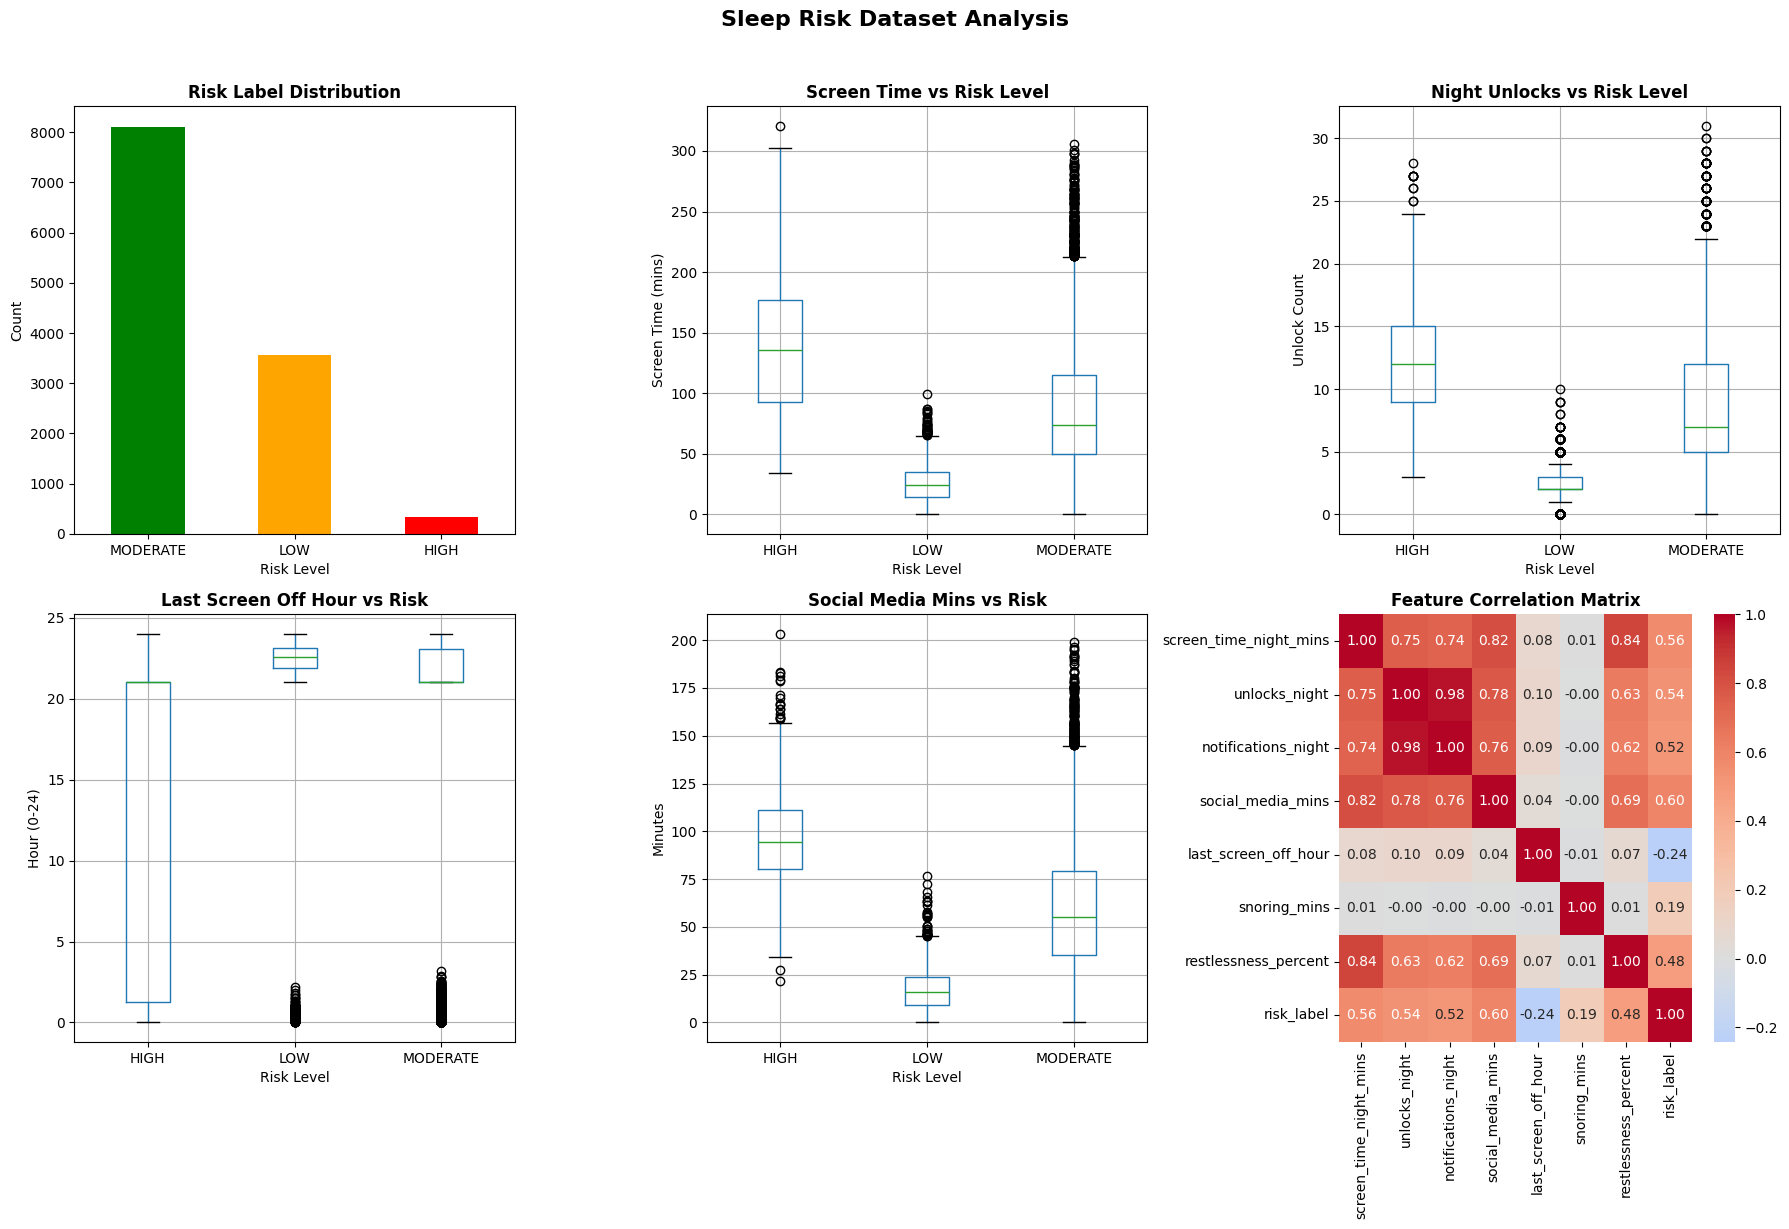

✅ Dataset saved to CSV


In [ ]:
# CELL 2 — Explore dataset

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Risk distribution
df['risk_name'].value_counts().plot(kind='bar', ax=axes[0,0],
                                    color=['green', 'orange', 'red'])
axes[0,0].set_title('Risk Label Distribution', fontweight='bold')
axes[0,0].set_xlabel('Risk Level')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(axis='x', rotation=0)

# 2. Screen time vs risk
df.boxplot(column='screen_time_night_mins', by='risk_name',
           ax=axes[0,1])
axes[0,1].set_title('Screen Time vs Risk Level', fontweight='bold')
axes[0,1].set_xlabel('Risk Level')
axes[0,1].set_ylabel('Screen Time (mins)')

# 3. Unlocks vs risk
df.boxplot(column='unlocks_night', by='risk_name', ax=axes[0,2])
axes[0,2].set_title('Night Unlocks vs Risk Level', fontweight='bold')
axes[0,2].set_xlabel('Risk Level')
axes[0,2].set_ylabel('Unlock Count')

# 4. Last screen time vs risk
df.boxplot(column='last_screen_off_hour', by='risk_name',
           ax=axes[1,0])
axes[1,0].set_title('Last Screen Off Hour vs Risk', fontweight='bold')
axes[1,0].set_xlabel('Risk Level')
axes[1,0].set_ylabel('Hour (0-24)')

# 5. Social media vs risk
df.boxplot(column='social_media_mins', by='risk_name', ax=axes[1,1])
axes[1,1].set_title('Social Media Mins vs Risk', fontweight='bold')
axes[1,1].set_xlabel('Risk Level')
axes[1,1].set_ylabel('Minutes')

# 6. Correlation heatmap
feature_cols = [
    'screen_time_night_mins', 'unlocks_night',
    'notifications_night', 'social_media_mins',
    'last_screen_off_hour', 'snoring_mins',
    'restlessness_percent', 'risk_label'
]
corr = df[feature_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[1,2], center=0)
axes[1,2].set_title('Feature Correlation Matrix', fontweight='bold')

plt.suptitle('Sleep Risk Dataset Analysis',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/dataset_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Save dataset
df.to_csv('/content/sleep_risk_dataset.csv', index=False)
print("✅ Dataset saved to CSV")

In [ ]:
# CELL 3 — Create sequential data for BiLSTM

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import numpy as np

SEQUENCE_LENGTH = 7  # 7 days of history
FEATURES = [
    'screen_time_night_mins',
    'unlocks_night',
    'notifications_night',
    'social_media_mins',
    'last_screen_off_hour',
    'snoring_mins',
    'restlessness_percent',
    'day_of_week',
]

def create_sequences(df, seq_length=7):
    """
    Create overlapping sequences of seq_length days.
    Each sequence uses past seq_length days to predict
    the next day's risk.
    """
    X_sequences = []
    y_labels = []
    user_ids = []

    for user_id in df['user_id'].unique():
        user_data = df[df['user_id'] == user_id].sort_values('day')

        if len(user_data) < seq_length + 1:
            continue

        # Get feature values
        feature_data = user_data[FEATURES].values
        label_data = user_data['risk_label'].values

        # Normalize features per user
        scaler = MinMaxScaler()
        feature_data = scaler.fit_transform(feature_data)

        # Create sequences
        for i in range(len(user_data) - seq_length):
            X_seq = feature_data[i:i + seq_length]
            y_label = label_data[i + seq_length]  # next day label

            X_sequences.append(X_seq)
            y_labels.append(y_label)
            user_ids.append(user_id)

    return np.array(X_sequences), np.array(y_labels)

print("Creating 7-day sequences...")
X_seq, y_seq = create_sequences(df, SEQUENCE_LENGTH)

print(f"X shape: {X_seq.shape}")  # (samples, 7, 8)
print(f"y shape: {y_seq.shape}")  # (samples,)
print(f"\nRisk distribution in sequences:")
unique, counts = np.unique(y_seq, return_counts=True)
for label, count in zip(['LOW','MODERATE','HIGH'], counts):
    print(f"  {label}: {count} ({count/len(y_seq)*100:.1f}%)")

Creating 7-day sequences...
X shape: (10600, 7, 8)
y shape: (10600,)

Risk distribution in sequences:
  LOW: 3115 (29.4%)
  MODERATE: 7198 (67.9%)
  HIGH: 287 (2.7%)


In [ ]:
# CELL 4 — Handle class imbalance

from imblearn.over_sampling import SMOTE

# Reshape for SMOTE (needs 2D)
n_samples, n_steps, n_features = X_seq.shape
X_reshaped = X_seq.reshape(n_samples, n_steps * n_features)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X_reshaped, y_seq)

# Reshape back to 3D
X_balanced = X_balanced.reshape(
    X_balanced.shape[0], n_steps, n_features
)

print(f"Before SMOTE: {X_seq.shape[0]} samples")
print(f"After SMOTE: {X_balanced.shape[0]} samples")
print(f"\nBalanced distribution:")
unique, counts = np.unique(y_balanced, return_counts=True)
for label, count in zip(['LOW','MODERATE','HIGH'], counts):
    print(f"  {label}: {count}")

Before SMOTE: 10600 samples
After SMOTE: 21594 samples

Balanced distribution:
  LOW: 7198
  MODERATE: 7198
  HIGH: 7198


In [ ]:
# CELL 5 — Split data

from tensorflow.keras.utils import to_categorical

# Split
X_temp, X_test, y_temp, y_test = train_test_split(
    X_balanced, y_balanced,
    test_size=0.15,
    random_state=42,
    stratify=y_balanced
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.176,  # ~15% of total
    random_state=42,
    stratify=y_temp
)

# One-hot encode labels for multi-class
y_train_cat = to_categorical(y_train, num_classes=3)
y_val_cat = to_categorical(y_val, num_classes=3)
y_test_cat = to_categorical(y_test, num_classes=3)

print(f"Training:   {X_train.shape[0]} samples")
print(f"Validation: {X_val.shape[0]} samples")
print(f"Testing:    {X_test.shape[0]} samples")
print(f"\nInput shape for model: {X_train.shape[1:]}")

Training:   15123 samples
Validation: 3231 samples
Testing:    3240 samples

Input shape for model: (7, 8)


In [ ]:
# CELL 6 — Build BiLSTM model

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Bidirectional, LSTM, Dense, Dropout,
    BatchNormalization, Input, GlobalAveragePooling1D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)

def build_bilstm_model(input_shape, n_classes=3):
    """
    Bidirectional LSTM for sleep risk prediction.
    Input: (7 days, 8 features)
    Output: (3,) probability for Low/Moderate/High
    """

    inputs = Input(shape=input_shape)

    # BiLSTM layers
    x = Bidirectional(
        LSTM(64, return_sequences=True, dropout=0.2)
    )(inputs)
    x = BatchNormalization()(x)

    x = Bidirectional(
        LSTM(32, return_sequences=True, dropout=0.2)
    )(x)
    x = BatchNormalization()(x)

    x = Bidirectional(
        LSTM(16, return_sequences=False)
    )(x)

    # Dense layers
    x = Dense(64, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)

    x = Dense(32, activation='relu')(x)
    x = Dropout(0.3)(x)

    # Output
    outputs = Dense(n_classes, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Build model
input_shape = (X_train.shape[1], X_train.shape[2])  # (7, 8)
model_risk = build_bilstm_model(input_shape)
model_risk.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 7, 8)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 7, 128)         │        37,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 7, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 7, 64)          │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 32)             │        10,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,275 (368.26 KB)

 Trainable params: 93,763 (366.26 KB)

 Non-trainable params: 512 (2.00 KB)

In [ ]:
# CELL 7 — Train the model

callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        '/content/best_risk_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print("🚀 Training BiLSTM model...")
history_risk = model_risk.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

print("\n✅ BiLSTM training completed!")

🚀 Training BiLSTM model...
Epoch 1/100
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4546 - loss: 1.1985
Epoch 1: val_accuracy improved from None to 0.56763, saving model to /content/best_risk_model.h5



Epoch 1: finished saving model to /content/best_risk_model.h5
473/473 ━━━━━━━━━━━━━━━━━━━━ 33s 28ms/step - accuracy: 0.4784 - loss: 1.0825 - val_accuracy: 0.5676 - val_loss: 0.8461 - learning_rate: 0.0010
Epoch 2/100
471/473 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5351 - loss: 0.9395
Epoch 2: val_accuracy improved from 0.56763 to 0.59641, saving model to /content/best_risk_model.h5



Epoch 2: finished saving model to /content/best_risk_model.h5
473/473 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.5404 - loss: 0.9287 - val_accuracy: 0.5964 - val_loss: 0.8102 - learning_rate: 0.0010
Epoch 3/100
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5669 - loss: 0.8928
Epoch 3: val_accuracy did not improve from 0.59641
473/473 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.5676 - loss: 0.8835 - val_accuracy: 0.5884 - val_loss: 0.8069 - learning_rate: 0.0010
Epoch 4/100
472/473 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5755 - loss: 0.8732
Epoch 4: val_accuracy improved from 0.59641 to 0.62303, saving model to /content/best_risk_model.h5



Epoch 4: finished saving model to /content/best_risk_model.h5
473/473 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.5838 - loss: 0.8632 - val_accuracy: 0.6230 - val_loss: 0.7603 - learning_rate: 0.0010
Epoch 5/100
471/473 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5926 - loss: 0.8557
Epoch 5: val_accuracy improved from 0.62303 to 0.63510, saving model to /content/best_risk_model.h5



Epoch 5: finished saving model to /content/best_risk_model.h5
473/473 ━━━━━━━━━━━━━━━━━━━━ 13s 28ms/step - accuracy: 0.5945 - loss: 0.8501 - val_accuracy: 0.6351 - val_loss: 0.7523 - learning_rate: 0.0010
Epoch 6/100
471/473 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6010 - loss: 0.8317
Epoch 6: val_accuracy improved from 0.63510 to 0.64345, saving model to /content/best_risk_model.h5


...


Epoch 14: finished saving model to /content/best_risk_model.h5
473/473 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.6915 - loss: 0.6895 - val_accuracy: 0.7320 - val_loss: 0.5860 - learning_rate: 0.0010
Epoch 15/100
472/473 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7096 - loss: 0.6765
Epoch 15: val_accuracy did not improve from 0.73197
473/473 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.7124 - loss: 0.6672 - val_accuracy: 0.7264 - val_loss: 0.5887 - learning_rate: 0.0010
Epoch 16/100
471/473 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7144 - loss: 0.6536
Epoch 16: val_accuracy did not improve from 0.73197
473/473 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - accuracy: 0.7125 - loss: 0.6548 - val_accuracy: 0.7233 - val_loss: 0.5859 - learning_rate: 0.0010
Epoch 17/100
472/473 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7191 - loss: 0.6381
Epoch 17: val_accuracy improved from 0.73197 to 0.74621, saving model to /content/best_risk_model.h5



Epoch 17: finished saving model to /content/best_risk_model.h5
473/473 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.7253 - loss: 0.6332 - val_accuracy: 0.7462 - val_loss: 0.6049 - learning_rate: 0.0010
Epoch 18/100
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7377 - loss: 0.6125
Epoch 18: val_accuracy improved from 0.74621 to 0.74807, saving model to /content/best_risk_model.h5



Epoch 18: finished saving model to /content/best_risk_model.h5
473/473 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.7389 - loss: 0.6134 - val_accuracy: 0.7481 - val_loss: 0.5632 - learning_rate: 0.0010
Epoch 19/100
471/473 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7456 - loss: 0.5920
Epoch 19: val_accuracy did not improve from 0.74807
473/473 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - accuracy: 0.7471 - loss: 0.5895 - val_accuracy: 0.7227 - val_loss: 0.6332 - learning_rate: 0.0010
Epoch 20/100
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7497 - loss: 0.5880
Epoch 20: val_accuracy improved from 0.74807 to 0.78211, saving model to /content/best_risk_model.h5



Epoch 20: finished saving model to /content/best_risk_model.h5
473/473 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.7525 - loss: 0.5805 - val_accuracy: 0.7821 - val_loss: 0.5086 - learning_rate: 0.0010
Epoch 21/100
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7542 - loss: 0.5797
Epoch 21: val_accuracy did not improve from 0.78211
473/473 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.7596 - loss: 0.5700 - val_accuracy: 0.7434 - val_loss: 0.6055 - learning_rate: 0.0010
Epoch 22/100
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7598 - loss: 0.5634
Epoch 22: val_accuracy did not improve from 0.78211
473/473 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.7637 - loss: 0.5638 - val_accuracy: 0.7366 - val_loss: 0.6626 - learning_rate: 0.0010
Epoch 23/100
472/473 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7740 - loss: 0.5357
Epoch 23: val_accuracy improved from 0.78211 to 0.81151, saving model to /content/best_risk_model.h5



Epoch 23: finished saving model to /content/best_risk_model.h5
473/473 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.7709 - loss: 0.5460 - val_accuracy: 0.8115 - val_loss: 0.4639 - learning_rate: 0.0010
Epoch 24/100
471/473 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7823 - loss: 0.5271
Epoch 24: val_accuracy did not improve from 0.81151
473/473 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.7814 - loss: 0.5304 - val_accuracy: 0.8063 - val_loss: 0.5063 - learning_rate: 0.0010
Epoch 25/100
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7788 - loss: 0.5332
Epoch 25: val_accuracy did not improve from 0.81151
473/473 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.7791 - loss: 0.5280 - val_accuracy: 0.7072 - val_loss: 0.7549 - learning_rate: 0.0010
Epoch 26/100
472/473 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7861 - loss: 0.5226
Epoch 26: val_accuracy did not improve from 0.81151
473/473 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.7869 - loss: 0.5148 - val_a

In [ ]:
# CELL 8 — Train baseline models for comparison

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
import pickle

# Reshape for sklearn (needs 2D)
X_train_2d = X_train.reshape(X_train.shape[0], -1)
X_val_2d = X_val.reshape(X_val.shape[0], -1)
X_test_2d = X_test.reshape(X_test.shape[0], -1)

results = {}

# 1. Logistic Regression
print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_2d, y_train)
lr_pred = lr.predict(X_test_2d)
results['Logistic Regression'] = {
    'accuracy': accuracy_score(y_test, lr_pred),
    'f1': f1_score(y_test, lr_pred, average='weighted')
}
print(f"  Accuracy: {results['Logistic Regression']['accuracy']*100:.2f}%")

# 2. Random Forest
print("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_2d, y_train)
rf_pred = rf.predict(X_test_2d)
results['Random Forest'] = {
    'accuracy': accuracy_score(y_test, rf_pred),
    'f1': f1_score(y_test, rf_pred, average='weighted')
}
print(f"  Accuracy: {results['Random Forest']['accuracy']*100:.2f}%")

# 3. SVM
print("Training SVM...")
svm = SVC(kernel='rbf', random_state=42, probability=True)
svm.fit(X_train_2d, y_train)
svm_pred = svm.predict(X_test_2d)
results['SVM'] = {
    'accuracy': accuracy_score(y_test, svm_pred),
    'f1': f1_score(y_test, svm_pred, average='weighted')
}
print(f"  Accuracy: {results['SVM']['accuracy']*100:.2f}%")

# 4. Gradient Boosting
print("Training Gradient Boosting...")
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train_2d, y_train)
gb_pred = gb.predict(X_test_2d)
results['Gradient Boosting'] = {
    'accuracy': accuracy_score(y_test, gb_pred),
    'f1': f1_score(y_test, gb_pred, average='weighted')
}
print(f"  Accuracy: {results['Gradient Boosting']['accuracy']*100:.2f}%")

# Save baseline models
with open('/content/random_forest_model.pkl', 'wb') as f:
    pickle.dump(rf, f)
print("\n✅ Random Forest saved (backup model)")

Training Logistic Regression...
  Accuracy: 64.20%
Training Random Forest...
  Accuracy: 91.23%
Training SVM...
  Accuracy: 87.93%
Training Gradient Boosting...
  Accuracy: 83.98%

✅ Random Forest saved (backup model)


102/102 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step

MODEL COMPARISON — SLEEP RISK PREDICTION
Model                       Accuracy   F1-Score
------------------------------------------------------------
Logistic Regression           64.20%     63.30%
Random Forest                 91.23%     91.19%
SVM                           87.93%     87.69%
Gradient Boosting             83.98%     83.82%
BiLSTM                        79.63%     78.36% ← BEST

Detailed BiLSTM Report:
              precision    recall  f1-score   support

         LOW       0.74      0.91      0.82      1080
    MODERATE       0.87      0.52      0.65      1080
        HIGH       0.82      0.96      0.88      1080

    accuracy                           0.80      3240
   macro avg       0.81      0.80      0.78      3240
weighted avg       0.81      0.80      0.78      3240



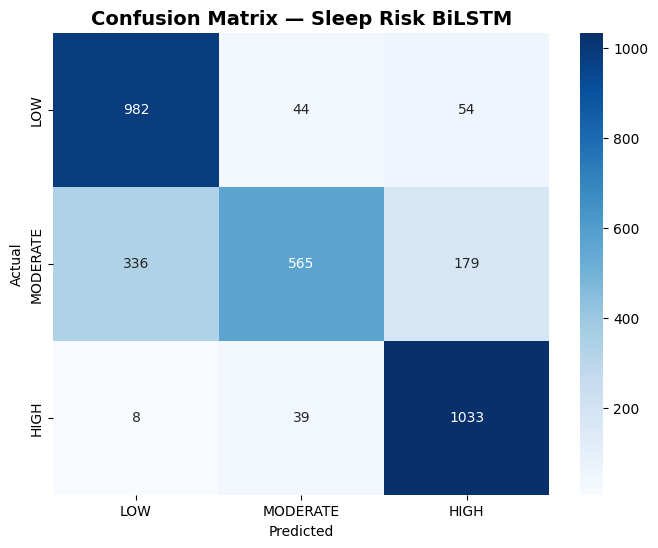

In [ ]:
# CELL 9 — Compare all models

from sklearn.metrics import confusion_matrix # Import confusion_matrix

# BiLSTM evaluation
y_pred_bilstm_prob = model_risk.predict(X_test)
y_pred_bilstm = np.argmax(y_pred_bilstm_prob, axis=1)
results['BiLSTM'] = {
    'accuracy': accuracy_score(y_test, y_pred_bilstm),
    'f1': f1_score(y_test, y_pred_bilstm, average='weighted')
}

# Print comparison table
print("\n" + "="*60)
print("MODEL COMPARISON — SLEEP RISK PREDICTION")
print("="*60)
print(f"{'Model':<25} {'Accuracy':>10} {'F1-Score':>10}")
print("-"*60)
for model_name, metrics in results.items():
    marker = " ← BEST" if model_name == 'BiLSTM' else ""
    print(f"{model_name:<25} "
          f"{metrics['accuracy']*100:>9.2f}% "
          f"{metrics['f1']*100:>9.2f}%"
          f"{marker}")
print("="*60)

# Detailed BiLSTM report
print("\nDetailed BiLSTM Report:")
print(classification_report(
    y_test, y_pred_bilstm,
    target_names=['LOW', 'MODERATE', 'HIGH']
))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_bilstm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['LOW', 'MODERATE', 'HIGH'],
            yticklabels=['LOW', 'MODERATE', 'HIGH'])
plt.title('Confusion Matrix — Sleep Risk BiLSTM',
          fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('/content/risk_confusion_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import json
import tensorflow as tf # Import tensorflow

# 1. Save Keras model
model_risk.save('/content/sleep_risk_model.h5')
print("✅ Saved: sleep_risk_model.h5")

# 2. Convert to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model_risk)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
# Apply the suggested fix for dynamic shape issues with TensorList operations
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS # Allow TensorFlow ops not natively supported by TFLite
]
converter._experimental_lower_tensor_list_ops = False # Disable problematic lowering
tflite_risk = converter.convert()

with open('/content/sleep_risk_model.tflite', 'wb') as f:
    f.write(tflite_risk)
print("✅ Saved: sleep_risk_model.tflite")

# 3. Save scaler and config
model_config = {
    "model_type": "sleep_risk_prediction",
    "sequence_length": 7,
    "n_features": len(FEATURES),
    "features": FEATURES,
    "n_classes": 3,
    "labels": {
        "0": "LOW",
        "1": "MODERATE",
        "2": "HIGH"
    },
    "version": "1.0"
}

with open('/content/sleep_risk_config.json', 'w') as f:
    json.dump(model_config, f, indent=2)
print("✅ Saved: sleep_risk_config.json")

# 4. Save dataset
df.to_csv('/content/sleep_risk_dataset.csv', index=False)
print("✅ Saved: sleep_risk_dataset.csv")

# 5. Download everything
from google.colab import files
files.download('/content/sleep_risk_model.h5')
files.download('/content/sleep_risk_model.tflite')
files.download('/content/sleep_risk_config.json')
files.download('/content/sleep_risk_dataset.csv')
files.download('/content/random_forest_model.pkl')
files.download('/content/dataset_analysis.png')
files.download('/content/risk_confusion_matrix.png')
print("\n✅ All Model 2 files downloaded!")

✅ Saved: sleep_risk_model.h5
Saved artifact at '/tmp/tmpznf2u_qd'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 7, 8), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  139238904547472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139238904549008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139238904551120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139238904551504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139238904547664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139240903299280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139238904548432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139238904550352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139238904550736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139238904548240: TensorSpec(shape=(), dtype=tf.resource, name=

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ All Model 2 files downloaded!
